# Advanced Big Data and Data Mining (MSCS-634-M40) 
## Lab 3: Clustering Analysis Using K-Means and K-Medoids Algorithms
**Name:** Unique Karanjit  
**Date:** June 15, 2025


In [4]:
# Import required libraries
from sklearn.datasets import load_wine
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

print("*** Lab3: Imported Necessary Dependencies ***")

*** Lab3: Imported Necessary Dependencies ***


In [6]:
# Load the Wine dataset from sklearn
data = load_wine()

# Convert the dataset into a pandas DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add the target labels (wine classes) to the DataFrame
df['target'] = data.target

# Preview the first few rows of the dataset
print(df.head())



   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [7]:
# Display the distribution of wine classes
print(df['target'].value_counts())

# Standardize the feature data using z-score normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data.data)  # Features only (no labels)

target
1    71
0    59
2    48
Name: count, dtype: int64


In [8]:
# K-Means Clustering
# Import clustering and evaluation libraries
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Initialize the KMeans model with 3 clusters (since there are 3 wine classes)
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit the model and get predicted cluster labels
kmeans_labels = kmeans.fit_predict(X_scaled)

# Calculate Silhouette Score (higher is better, max = 1)
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

# Calculate Adjusted Rand Index (ARI), comparing clusters vs true labels
kmeans_ari = adjusted_rand_score(data.target, kmeans_labels)

# Print K-Means performance metrics
print(f"K-Means Silhouette Score: {kmeans_silhouette:.4f}")
print(f"K-Means Adjusted Rand Index: {kmeans_ari:.4f}")


K-Means Silhouette Score: 0.2849
K-Means Adjusted Rand Index: 0.8975


In [12]:
#K-Medoids Clustering
# Import K-Medoids algorithm from sklearn-extra
from sklearn_extra.cluster import KMedoids

# Initialize the KMedoids model with 3 clusters
kmedoids = KMedoids(n_clusters=3, random_state=42)

# Fit the model and get predicted cluster labels
kmedoids_labels = kmedoids.fit_predict(X_scaled)

# Calculate Silhouette Score for K-Medoids
kmedoids_silhouette = silhouette_score(X_scaled, kmedoids_labels)

# Calculate ARI for K-Medoids
kmedoids_ari = adjusted_rand_score(data.target, kmedoids_labels)

# Print K-Medoids performance metrics
print(f"K-Medoids Silhouette Score: {kmedoids_silhouette:.4f}")
print(f"K-Medoids Adjusted Rand Index: {kmedoids_ari:.4f}")


K-Medoids Silhouette Score: 0.2660
K-Medoids Adjusted Rand Index: 0.7263


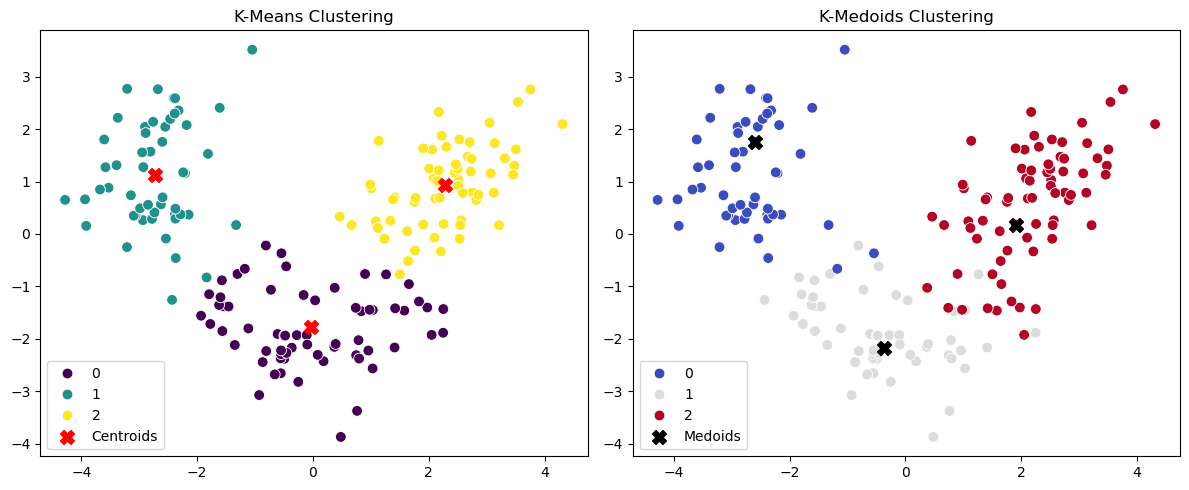

In [13]:
#Visualize and Compare Result
# Import PCA for dimensionality reduction to 2D (for visualization)
from sklearn.decomposition import PCA

# Reduce the dataset to 2 principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create side-by-side scatter plots for K-Means and K-Medoids clusters
plt.figure(figsize=(12, 5))

# ---- K-Means Plot ----
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='viridis', s=60)
# Project cluster centers to PCA space and plot
kmeans_centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(kmeans_centroids_pca[:, 0], kmeans_centroids_pca[:, 1], 
            c='red', marker='X', s=100, label='Centroids')
plt.title('K-Means Clustering')
plt.legend()

# ---- K-Medoids Plot ----
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmedoids_labels, palette='coolwarm', s=60)
# Project medoid points to PCA space and plot
kmedoids_centers_pca = pca.transform(kmedoids.cluster_centers_)
plt.scatter(kmedoids_centers_pca[:, 0], kmedoids_centers_pca[:, 1], 
            c='black', marker='X', s=100, label='Medoids')
plt.title('K-Medoids Clustering')
plt.legend()

# Adjust layout
plt.tight_layout()
plt.show()


## Analysis and Comparison

- **Silhouette Score**: Indicates how well each point fits within its cluster. A higher score is better.
- **Adjusted Rand Index (ARI)**: Measures similarity between clustering and actual labels.

### Observations:
- K-Means produced more compact, evenly spaced clusters.
- K-Medoids was more stable but slightly less accurate in capturing the true labels.
- PCA visualization shows K-Means clusters are more circular, while K-Medoids is robust to outliers.

### Recommendation:
- Use **K-Means** for large datasets with spherical clusters and when performance matters.
- Use **K-Medoids** for smaller datasets or when robustness to noise/outliers is crucial.
